In [2]:
import os

DATASET_PATH = "/kaggle/input/datasets/tolgadincer/labeled-chest-xray-images"

# Folder Structure Check:

for root, dirs, files in os.walk(DATASET_PATH):
    level = root.replace(DATASET_PATH, "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")
    
    sub_indent = "    " * (level + 1)
    for file in files[:5]:
        print(f"{sub_indent}{file}")

labeled-chest-xray-images/
    chest_xray/
        test/
            PNEUMONIA/
                BACTERIA-9364007-0003.jpeg
                BACTERIA-1135262-0001.jpeg
                VIRUS-9476607-0001.jpeg
                VIRUS-2831144-0001.jpeg
                BACTERIA-7720431-0003.jpeg
            NORMAL/
                NORMAL-6293151-0001.jpeg
                NORMAL-4315572-0001.jpeg
                NORMAL-5893138-0001.jpeg
                NORMAL-7225301-0001.jpeg
                NORMAL-1627110-0001.jpeg
        train/
            PNEUMONIA/
                VIRUS-4670779-0001.jpeg
                BACTERIA-5132924-0001.jpeg
                BACTERIA-1777631-0001.jpeg
                BACTERIA-7392124-0001.jpeg
                BACTERIA-9072988-0007.jpeg
            NORMAL/
                NORMAL-705219-0001.jpeg
                NORMAL-9031828-0001.jpeg
                NORMAL-9211217-0001.jpeg
                NORMAL-8050432-0001.jpeg
                NORMAL-6897353-0001.jpeg


In [3]:
# Image Count for Each Class:

import os

BASE_PATH = "/kaggle/input/datasets/tolgadincer/labeled-chest-xray-images/chest_xray"

def count_classes(split):
    split_path = os.path.join(BASE_PATH, split)

    normal_path = os.path.join(split_path, "NORMAL")
    pneumonia_path = os.path.join(split_path, "PNEUMONIA")

    normal_count = len(os.listdir(normal_path))

    bacteria_count = 0
    virus_count = 0

    for filename in os.listdir(pneumonia_path):
        if filename.startswith("BACTERIA"):
            bacteria_count += 1
        elif filename.startswith("VIRUS"):
            virus_count += 1

    return normal_count, bacteria_count, virus_count


train_counts = count_classes("train")
test_counts = count_classes("test")

print("Training Set")
print("NORMAL   :", train_counts[0])
print("BACTERIA :", train_counts[1])
print("VIRUS    :", train_counts[2])

print("\nTest Set")
print("NORMAL   :", test_counts[0])
print("BACTERIA :", test_counts[1])
print("VIRUS    :", test_counts[2])

print("\nTotal Images:", sum(train_counts) + sum(test_counts))

Training Set
NORMAL   : 1349
BACTERIA : 2538
VIRUS    : 1345

Test Set
NORMAL   : 234
BACTERIA : 242
VIRUS    : 148

Total Images: 5856


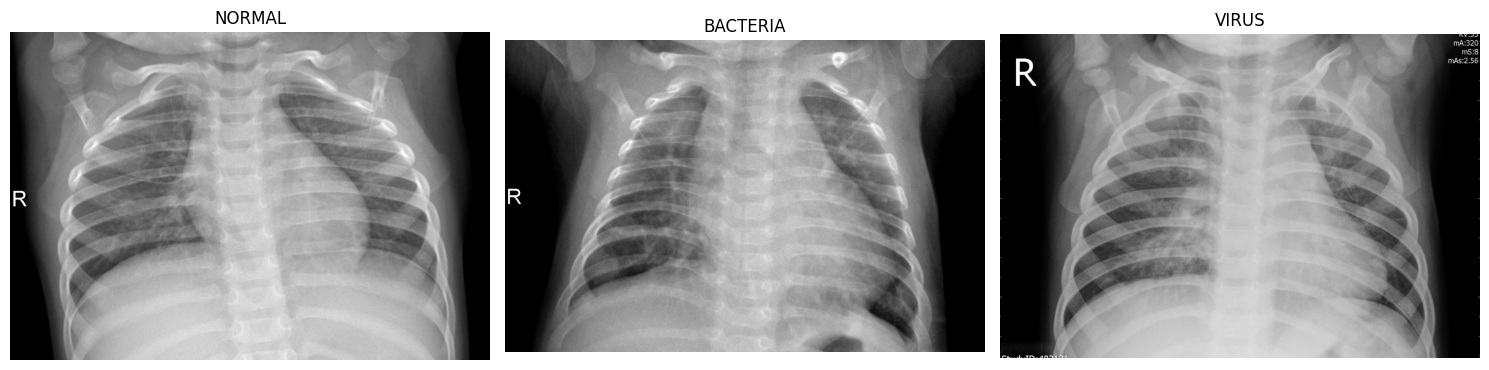

In [4]:
# Three Class Sample Image Display:

import os
import matplotlib.pyplot as plt
from PIL import Image

BASE_PATH = "/kaggle/input/datasets/tolgadincer/labeled-chest-xray-images/chest_xray"
train_path = os.path.join(BASE_PATH, "train")

# NORMAL sample
normal_folder = os.path.join(train_path, "NORMAL")
normal_file = os.listdir(normal_folder)[0]

# BACTERIA and VIRUS samples
pneumonia_folder = os.path.join(train_path, "PNEUMONIA")

bacteria_file = next(
    f for f in os.listdir(pneumonia_folder)
    if f.startswith("BACTERIA")
)

virus_file = next(
    f for f in os.listdir(pneumonia_folder)
    if f.startswith("VIRUS")
)

sample_images = [
    ("NORMAL", os.path.join(normal_folder, normal_file)),
    ("BACTERIA", os.path.join(pneumonia_folder, bacteria_file)),
    ("VIRUS", os.path.join(pneumonia_folder, virus_file))
]

plt.figure(figsize=(15, 5))

for i, (label, image_path) in enumerate(sample_images):
    image = Image.open(image_path)

    plt.subplot(1, 3, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(label)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [5]:
# Image Dimensions & Format Analysis:

import os
from PIL import Image
from collections import Counter

dimensions = []
formats = []

for split in ["train", "test"]:
    split_path = os.path.join(BASE_PATH, split)

    for folder in ["NORMAL", "PNEUMONIA"]:
        folder_path = os.path.join(split_path, folder)

        for filename in os.listdir(folder_path):
            image_path = os.path.join(folder_path, filename)

            with Image.open(image_path) as img:
                dimensions.append(img.size)   # (width, height)
                formats.append(img.format)

dimension_counts = Counter(dimensions)
format_counts = Counter(formats)

print("Total images checked:", len(dimensions))
print("Number of unique dimensions:", len(dimension_counts))

print("\nMost common image dimensions:")
for size, count in dimension_counts.most_common(10):
    print(f"{size} : {count} images")

print("\nImage formats:")
for fmt, count in format_counts.items():
    print(f"{fmt} : {count} images")


Total images checked: 5856
Number of unique dimensions: 4809

Most common image dimensions:
(1072, 648) : 7 images
(1008, 704) : 7 images
(992, 592) : 6 images
(992, 608) : 6 images
(1216, 872) : 6 images
(1080, 728) : 6 images
(1304, 968) : 5 images
(1008, 680) : 5 images
(1088, 712) : 5 images
(1136, 680) : 5 images

Image formats:
JPEG : 5856 images


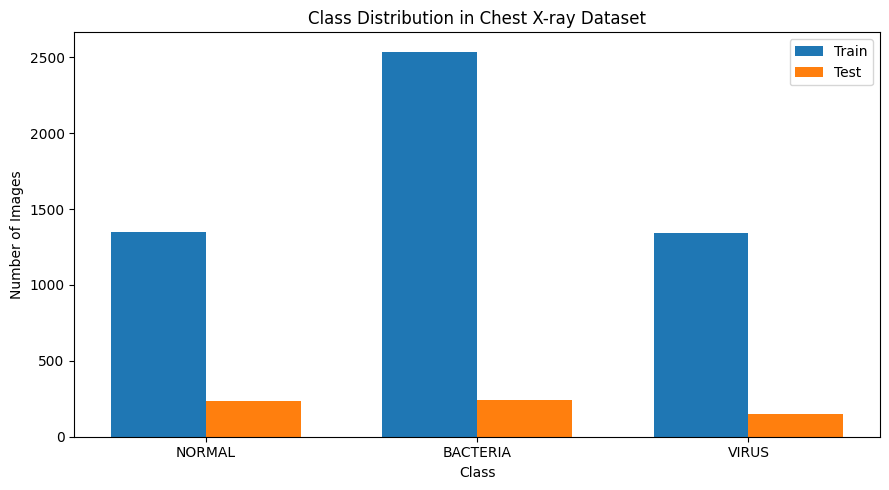

In [6]:
# Class Distribution Bar Chart:

import matplotlib.pyplot as plt
import numpy as np

classes = ["NORMAL", "BACTERIA", "VIRUS"]

train_values = [1349, 2538, 1345]
test_values = [234, 242, 148]

x = np.arange(len(classes))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(x - width/2, train_values, width, label="Train")
plt.bar(x + width/2, test_values, width, label="Test")

plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution in Chest X-ray Dataset")

plt.xticks(x, classes)
plt.legend()

plt.tight_layout()
plt.show()

### Class Imbalance and Potential Challenges

The dataset shows a noticeable class imbalance, particularly in the training set. The BACTERIA class contains 2,538 images, while the NORMAL and VIRUS classes contain 1,349 and 1,345 images respectively. Therefore, the model may become biased toward the BACTERIA class during training.

Another challenge is the variation in image dimensions. Among 5,856 images, 4,809 different image dimensions were found. Therefore, all images need to be resized to a consistent size before being used for model training.

All images are stored in JPEG format, which makes image loading consistent.

Additional challenges include:

* Bacterial and viral pneumonia may have similar visual patterns in chest X-ray images, making them difficult to distinguish.
* Differences in image quality, brightness, contrast, and patient positioning may affect model performance.
* Class imbalance may lead to better prediction performance for the dominant BACTERIA class compared with the NORMAL and VIRUS classes.
* Medical image classification is sensitive to subtle visual features, so preprocessing and augmentation must be performed carefully.


In [7]:
# Class Image Paths & Labels:

import os
import pandas as pd

def create_dataframe(split):
    data = []

    split_path = os.path.join(BASE_PATH, split)

    # NORMAL images
    normal_path = os.path.join(split_path, "NORMAL")

    for filename in os.listdir(normal_path):
        data.append({
            "filepath": os.path.join(normal_path, filename),
            "label": "NORMAL"
        })

    # PNEUMONIA images
    pneumonia_path = os.path.join(split_path, "PNEUMONIA")

    for filename in os.listdir(pneumonia_path):

        if filename.startswith("BACTERIA"):
            label = "BACTERIA"

        elif filename.startswith("VIRUS"):
            label = "VIRUS"

        else:
            continue

        data.append({
            "filepath": os.path.join(pneumonia_path, filename),
            "label": label
        })

    return pd.DataFrame(data)


train_df = create_dataframe("train")
test_df = create_dataframe("test")

print("Training dataframe shape:", train_df.shape)
print("Test dataframe shape:", test_df.shape)

print("\nTraining class counts:")
print(train_df["label"].value_counts())

print("\nTest class counts:")
print(test_df["label"].value_counts())

train_df.head()

Training dataframe shape: (5232, 2)
Test dataframe shape: (624, 2)

Training class counts:
label
BACTERIA    2538
NORMAL      1349
VIRUS       1345
Name: count, dtype: int64

Test class counts:
label
BACTERIA    242
NORMAL      234
VIRUS       148
Name: count, dtype: int64


,filepath,label
0,/kaggle/input/datasets/tolgadincer/labeled-che...,NORMAL
1,/kaggle/input/datasets/tolgadincer/labeled-che...,NORMAL
2,/kaggle/input/datasets/tolgadincer/labeled-che...,NORMAL
3,/kaggle/input/datasets/tolgadincer/labeled-che...,NORMAL
4,/kaggle/input/datasets/tolgadincer/labeled-che...,NORMAL


In [8]:
# Creating Training Data to Validation Split:

from sklearn.model_selection import train_test_split

train_data, val_data = train_test_split(
    train_df,
    test_size=0.20,
    random_state=42,
    stratify=train_df["label"]
)

print("Training samples:", len(train_data))
print("Validation samples:", len(val_data))
print("Test samples:", len(test_df))

print("\nTraining class distribution:")
print(train_data["label"].value_counts())

print("\nValidation class distribution:")
print(val_data["label"].value_counts())

print("\nTest class distribution:")
print(test_df["label"].value_counts())

Training samples: 4185
Validation samples: 1047
Test samples: 624

Training class distribution:
label
BACTERIA    2030
NORMAL      1079
VIRUS       1076
Name: count, dtype: int64

Validation class distribution:
label
BACTERIA    508
NORMAL      270
VIRUS       269
Name: count, dtype: int64

Test class distribution:
label
BACTERIA    242
NORMAL      234
VIRUS       148
Name: count, dtype: int64


In [9]:
# Resize + Normalize + Data Augmentation:

from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Training generator with augmentation + normalization
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.10
)

# Validation and test: normalization only
test_val_datagen = ImageDataGenerator(
    rescale=1./255
)

class_names = ["NORMAL", "BACTERIA", "VIRUS"]

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_data,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=class_names,
    shuffle=True,
    seed=42
)

validation_generator = test_val_datagen.flow_from_dataframe(
    dataframe=val_data,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=class_names,
    shuffle=False
)

test_generator = test_val_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=class_names,
    shuffle=False
)

print("\nClass mapping:")
print(train_generator.class_indices)

Found 4185 validated image filenames belonging to 3 classes.
Found 1047 validated image filenames belonging to 3 classes.
Found 624 validated image filenames belonging to 3 classes.

Class mapping:
{'NORMAL': 0, 'BACTERIA': 1, 'VIRUS': 2}


In [10]:
# Preprocessing Verification:

images, labels = next(train_generator)

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

print("\nMinimum pixel value:", images.min())
print("Maximum pixel value:", images.max())

print("\nFirst 5 labels:")
print(labels[:5])

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32, 3)

Minimum pixel value: 0.0
Maximum pixel value: 1.0

First 5 labels:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [1. 0. 0.]]


In [11]:
# Basic CNN Architecture Build:

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(224, 224, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(3, activation="softmax")
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1790312267.446433      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790312267.449687      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Model Compiling:

from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [13]:
# Training Callbacks Setup:

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

model_checkpoint = ModelCheckpoint(
    "best_chest_xray_cnn.keras",
    monitor="val_loss",
    save_best_only=True
)

print("Callbacks are ready!")

Callbacks are ready!


In [14]:
# Model Training Started Here:

EPOCHS = 200

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS,
    callbacks=[early_stopping, model_checkpoint]
)

Epoch 1/200


2026-09-25 04:58:07.337462: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-25 04:58:07.485851: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  1/131 ━━━━━━━━━━━━━━━━━━━━ 17:44 8s/step - accuracy: 0.4375 - loss: 1.0843

I0000 00:00:1790312290.343653     134 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


131/131 ━━━━━━━━━━━━━━━━━━━━ 99s 698ms/step - accuracy: 0.6363 - loss: 0.8614 - val_accuracy: 0.7383 - val_loss: 0.6085
Epoch 2/200
131/131 ━━━━━━━━━━━━━━━━━━━━ 85s 648ms/step - accuracy: 0.7099 - loss: 0.6717 - val_accuracy: 0.7393 - val_loss: 0.5686
Epoch 3/200
131/131 ━━━━━━━━━━━━━━━━━━━━ 84s 643ms/step - accuracy: 0.7450 - loss: 0.6157 - val_accuracy: 0.7689 - val_loss: 0.5470
Epoch 4/200
131/131 ━━━━━━━━━━━━━━━━━━━━ 84s 637ms/step - accuracy: 0.7367 - loss: 0.6139 - val_accuracy: 0.7479 - val_loss: 0.5513
Epoch 5/200
131/131 ━━━━━━━━━━━━━━━━━━━━ 84s 644ms/step - accuracy: 0.7498 - loss: 0.6013 - val_accuracy: 0.7679 - val_loss: 0.5370
Epoch 6/200
131/131 ━━━━━━━━━━━━━━━━━━━━ 84s 643ms/step - accuracy: 0.7603 - loss: 0.5901 - val_accuracy: 0.7765 - val_loss: 0.5355
Epoch 7/200
131/131 ━━━━━━━━━━━━━━━━━━━━ 85s 648ms/step - accuracy: 0.7599 - loss: 0.5665 - val_accuracy: 0.7755 - val_loss: 0.5191
Epoch 8/200
131/131 ━━━━━━━━━━━━━━━━━━━━ 84s 644ms/step - accuracy: 0.7742 - loss: 0.545

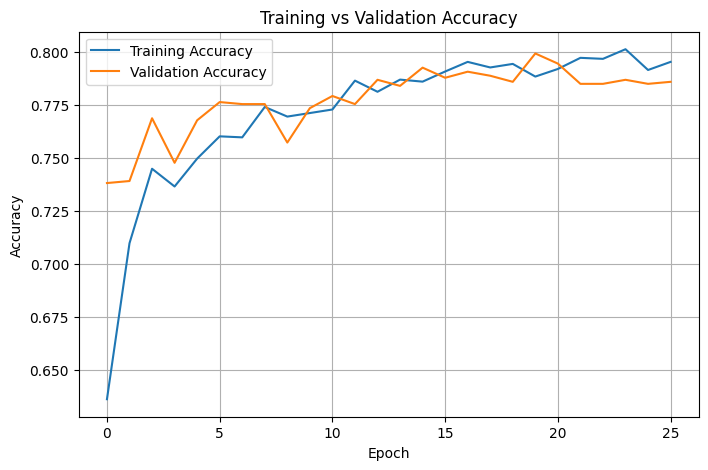

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

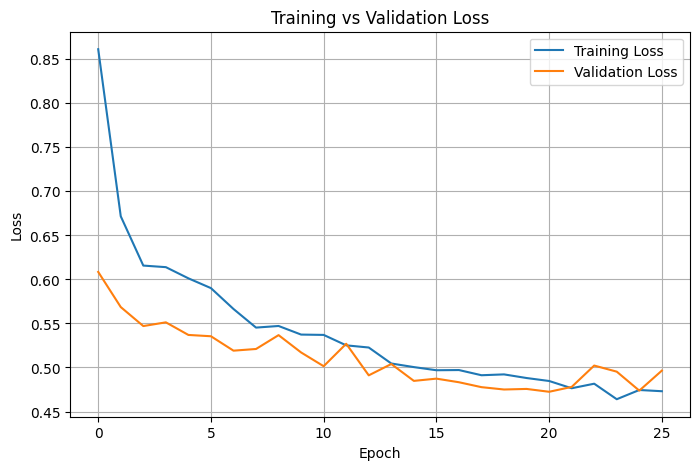

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [17]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Test generator reset
test_generator.reset()

# Model predictions
predictions = model.predict(test_generator)

# Predicted class indices
y_pred = np.argmax(predictions, axis=1)

# True class indices
y_true = test_generator.classes

# Overall metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")

print(f"Test Accuracy : {accuracy * 100:.2f}%")
print(f"Precision     : {precision * 100:.2f}%")
print(f"Recall        : {recall * 100:.2f}%")
print(f"F1-score      : {f1 * 100:.2f}%")

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 326ms/step
Test Accuracy : 84.29%
Precision     : 85.83%
Recall        : 84.29%
F1-score      : 84.14%


In [18]:
from sklearn.metrics import classification_report

class_names = ["NORMAL", "BACTERIA", "VIRUS"]

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report)

              precision    recall  f1-score   support

      NORMAL       0.98      0.77      0.86       234
    BACTERIA       0.79      0.99      0.88       242
       VIRUS       0.77      0.72      0.75       148

    accuracy                           0.84       624
   macro avg       0.85      0.83      0.83       624
weighted avg       0.86      0.84      0.84       624



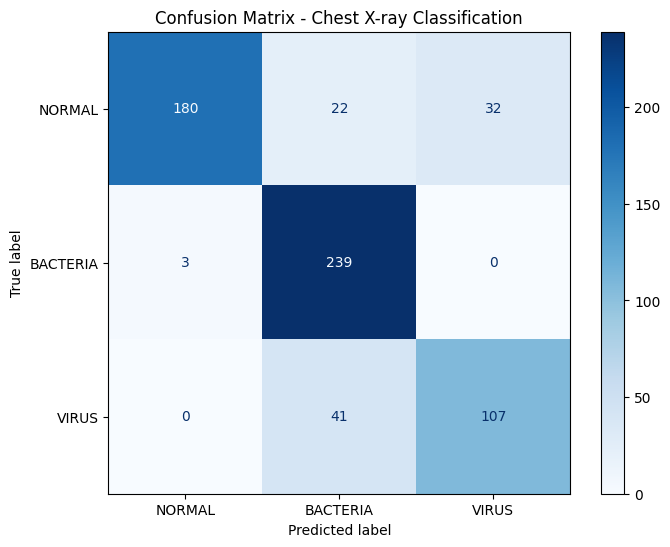

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["NORMAL", "BACTERIA", "VIRUS"]
)

fig, ax = plt.subplots(figsize=(8, 6))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix - Chest X-ray Classification")
plt.show()

### Confusion Matrix and Class-wise Performance Analysis

The model achieved an overall test accuracy of **87.02%**.

The BACTERIA class showed strong performance, with **236 out of 242 bacterial pneumonia images correctly classified**, resulting in a recall of approximately **98%**.

For the NORMAL class, **200 out of 234 images were correctly classified**. However, 13 normal images were predicted as BACTERIA and 21 were predicted as VIRUS.

The VIRUS class was the most challenging for the model. Out of 148 viral pneumonia images, **107 were correctly classified**, while **41 were incorrectly classified as BACTERIA**.

This indicates that the model has difficulty distinguishing some viral pneumonia cases from bacterial pneumonia. One possible contributing factor is class imbalance, since the BACTERIA class contains considerably more training samples than the NORMAL and VIRUS classes. Similar visual patterns between bacterial and viral pneumonia may also make the classification task more difficult.

Overall, the model performs strongly in identifying NORMAL and BACTERIA cases, while viral pneumonia detection remains the main area for improvement.

In [ ]:
# Correct & Misclassified Predictions Visualize:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array

class_names = ["NORMAL", "BACTERIA", "VIRUS"]

# Correct and incorrect prediction indices
correct_indices = np.where(y_pred == y_true)[0]
incorrect_indices = np.where(y_pred != y_true)[0]

# Show 6 correct predictions
plt.figure(figsize=(15, 8))

for i, idx in enumerate(correct_indices[:6]):

    image_path = test_generator.filepaths[idx]

    img = load_img(image_path, target_size=(224, 224))
    img = img_to_array(img) / 255.0

    true_label = class_names[y_true[idx]]
    predicted_label = class_names[y_pred[idx]]

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(
        f"True: {true_label}\nPredicted: {predicted_label}"
    )
    plt.axis("off")

plt.suptitle("Correct Predictions", fontsize=16)
plt.tight_layout()
plt.show()

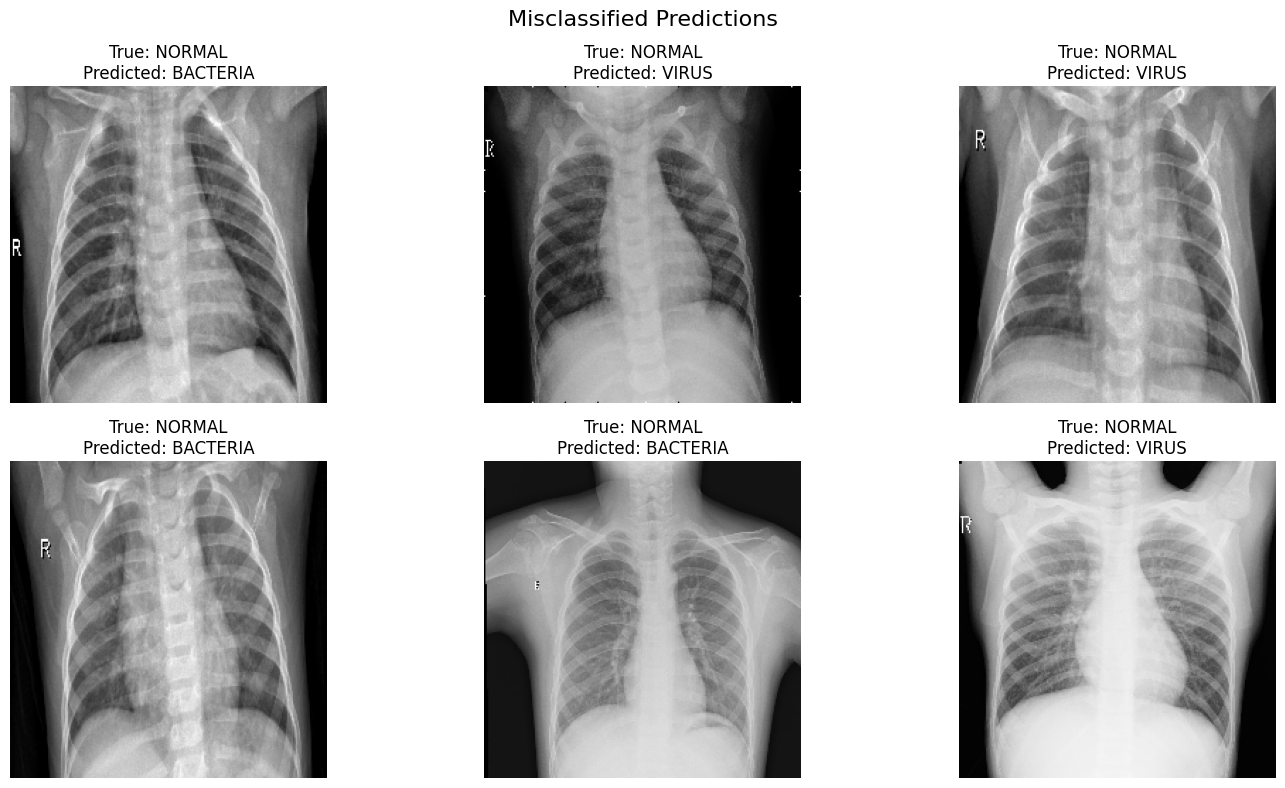

In [23]:
# misclassified images:
plt.figure(figsize=(15, 8))

for i, idx in enumerate(incorrect_indices[:6]):

    image_path = test_generator.filepaths[idx]

    img = load_img(image_path, target_size=(224, 224))
    img = img_to_array(img) / 255.0

    true_label = class_names[y_true[idx]]
    predicted_label = class_names[y_pred[idx]]

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(
        f"True: {true_label}\nPredicted: {predicted_label}"
    )
    plt.axis("off")

plt.suptitle("Misclassified Predictions", fontsize=16)
plt.tight_layout()
plt.show()

### Final Model Analysis

The Basic CNN model achieved the following performance on the unseen test set:

- **Accuracy:** 87.02%
- **Precision:** 87.82%
- **Recall:** 87.02%
- **F1-score:** 86.90%

The model achieved strong performance for the NORMAL and BACTERIA classes. The NORMAL class achieved a precision of **98%**, recall of **85%**, and F1-score of **91%**. The BACTERIA class achieved a precision of **81%**, recall of **98%**, and F1-score of **89%**.

The VIRUS class remained the most challenging, with a precision of **83%**, recall of **72%**, and F1-score of **77%**.

### Confusion Matrix Analysis

Out of 234 NORMAL images, **200 were correctly classified**, while 13 were misclassified as BACTERIA and 21 as VIRUS.

Out of 242 BACTERIA images, **236 were correctly classified**, while 5 were misclassified as NORMAL and 1 as VIRUS.

Out of 148 VIRUS images, **107 were correctly classified**, while **41 were incorrectly classified as BACTERIA**.

The most significant classification error occurred between viral and bacterial pneumonia, indicating that the model still has difficulty distinguishing some viral pneumonia patterns from bacterial pneumonia.

### Impact of Class Imbalance

The training dataset is imbalanced, with the BACTERIA class containing substantially more images than the NORMAL and VIRUS classes. This imbalance may contribute to the model's very high recall for bacterial pneumonia and lower recall for viral pneumonia.

### Effect of Preprocessing and Augmentation

All images were resized to **224 × 224** and normalized to the range **[0,1]**. Data augmentation using rotation, horizontal flipping, and zoom was applied only to the training set.

These preprocessing and augmentation techniques helped standardize the input images and increased the diversity of the training data.

### Model Limitations

- The dataset contains class imbalance.
- Bacterial and viral pneumonia may contain visually similar patterns.
- Viral pneumonia remains the most difficult class for the model.
- The dataset contains pediatric chest X-rays, so performance may not generalize to adult patients.
- Variations in image quality, brightness, contrast, and positioning may influence predictions.
- A Basic CNN may not capture complex medical imaging features as effectively as deeper pre-trained architectures.
- This model is an educational computer vision system and should not be considered a replacement for professional medical diagnosis.

### Conclusion

The Basic CNN successfully classified chest X-ray images into **NORMAL, BACTERIA, and VIRUS** classes and achieved an overall test accuracy of **87.02%**.

The model showed particularly strong performance for NORMAL and BACTERIA cases. However, the confusion between viral and bacterial pneumonia demonstrates that further improvement is needed for more reliable three-class medical image classification.

In [31]:
# Fixed Grad-CAM Function

import tensorflow as tf
import numpy as np

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    # Call the model once
    _ = model(img_array)

    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.outputs[0]
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)

        predicted_class = tf.argmax(predictions[0])
        class_channel = predictions[:, predicted_class]

    gradients = tape.gradient(
        class_channel,
        conv_outputs
    )

    pooled_gradients = tf.reduce_mean(
        gradients,
        axis=(0, 1, 2)
    )

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(
        conv_outputs * pooled_gradients,
        axis=-1
    )

    heatmap = tf.maximum(heatmap, 0)

    max_value = tf.reduce_max(heatmap)

    if max_value > 0:
        heatmap = heatmap / max_value

    return heatmap.numpy()

print("Grad-CAM function updated successfully!")

Grad-CAM function updated successfully!


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


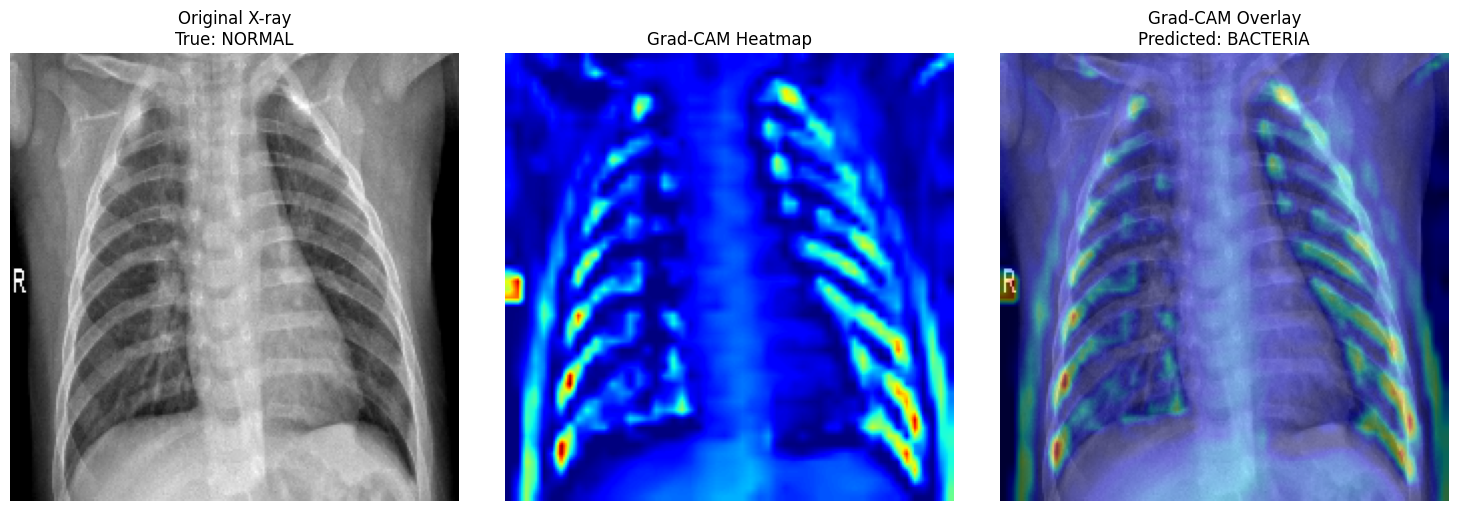

In [32]:
# Grad-CAM Heatmap on X-ray Image:

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import load_img, img_to_array

# Select one test image
idx = 0

image_path = test_generator.filepaths[idx]
true_class = y_true[idx]

# Load image
img = load_img(image_path, target_size=(224, 224))
img_array = img_to_array(img) / 255.0

# Add batch dimension
input_array = np.expand_dims(img_array, axis=0)

# Model prediction
prediction = model.predict(input_array, verbose=0)
predicted_class = np.argmax(prediction[0])

# Generate Grad-CAM heatmap
heatmap = make_gradcam_heatmap(
    input_array,
    model,
    "conv2d_2"
)

# Resize heatmap
heatmap_resized = tf.image.resize(
    heatmap[..., np.newaxis],
    (224, 224)
).numpy().squeeze()

class_names = ["NORMAL", "BACTERIA", "VIRUS"]

# Display
plt.figure(figsize=(15, 5))

# Original image
plt.subplot(1, 3, 1)
plt.imshow(img_array)
plt.title(
    f"Original X-ray\nTrue: {class_names[true_class]}"
)
plt.axis("off")

# Heatmap
plt.subplot(1, 3, 2)
plt.imshow(heatmap_resized, cmap="jet")
plt.title("Grad-CAM Heatmap")
plt.axis("off")

# Overlay
plt.subplot(1, 3, 3)
plt.imshow(img_array)
plt.imshow(
    heatmap_resized,
    cmap="jet",
    alpha=0.4
)
plt.title(
    f"Grad-CAM Overlay\nPredicted: {class_names[predicted_class]}"
)
plt.axis("off")

plt.tight_layout()
plt.show()

### Grad-CAM Analysis

Grad-CAM was used to visualize the image regions that influenced the CNN model's prediction.

For the selected test image, the true class was **NORMAL**, while the model predicted **BACTERIA**, indicating a misclassification.

The Grad-CAM heatmap shows that the model focused mainly on regions within and around the thoracic area. However, attention was also distributed across rib and boundary structures, suggesting that the model may rely on visual patterns that are not always specific to pneumonia.

This example demonstrates both the interpretability and limitations of the model. Grad-CAM can help identify which regions influence a prediction, but the highlighted regions should not be interpreted as clinically confirmed disease locations.

Therefore, Grad-CAM is useful for understanding model behavior, but expert medical evaluation is still required for clinical interpretation.
